# Classification: Decision Trees, Random Forest & KNN
## Titanic Survival Prediction - Session 2


In [ ]:
# Import all tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.tree            import DecisionTreeClassifier, plot_tree
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.metrics         import accuracy_score, confusion_matrix

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

print("✅ All libraries imported!")


✅ All libraries imported!


---
## Step 0: Where We Left Off Last Class

Last time we built a **preprocessing pipeline** for the Titanic dataset:
- Filled missing values
- Encoded categorical columns
- Split into train/test
- Scaled numerical features

Let's run it quickly to get our data ready.


In [ ]:
# Preprocessing pipeline from last session
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df_raw = pd.read_csv(url)

# --- Clean ---
df_raw['Age']      = df_raw['Age'].fillna(df_raw['Age'].median())
df_raw['Embarked'] = df_raw['Embarked'].fillna(df_raw['Embarked'].mode()[0])
df_raw = df_raw.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])
df_raw['Sex'] = df_raw['Sex'].map({'male': 0, 'female': 1})
df_raw = pd.get_dummies(df_raw, columns=['Embarked'], drop_first=True)

# --- Split FIRST, then scale ---
X = df_raw.drop(columns=['Survived'])
y = df_raw['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
scale_cols = ['Age', 'Fare', 'SibSp', 'Parch']
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print("Data is ready!")
print(f"  Training samples : {X_train.shape[0]}")
print(f"  Test samples     : {X_test.shape[0]}")
print(f"  Features         : {list(X.columns)}")


Data is ready!
  Training samples : 712
  Test samples     : 179
  Features         : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


---
## Part 1: Decision Trees

### What is a Decision Tree?

Think of it like the **"20 Questions"** game:

> "Is it an animal?" → Yes  
> "Does it have 4 legs?" → Yes  
> "Can it fly?" → No → **It's a dog! 🐕**

The computer asks a series of **YES / NO questions** about the data,  
and at the end; it gives a prediction. **That's literally it!**

---

### For Titanic, it might ask:
1. *Is the passenger female?* → **Yes** → Likely Survived ✅  
2. *No?* → *Is it 1st Class?* → **Yes** → Likely Survived ✅  
3. *Still No?* → **Probably didn't survive** ❌

---

**Key terms:**
- **Root node** = First question (the most important one)
- **Internal node** = A question in the middle
- **Leaf node** = Final answer (Survived / Not Survived)
- **Depth** = How many questions deep we allow the tree to go


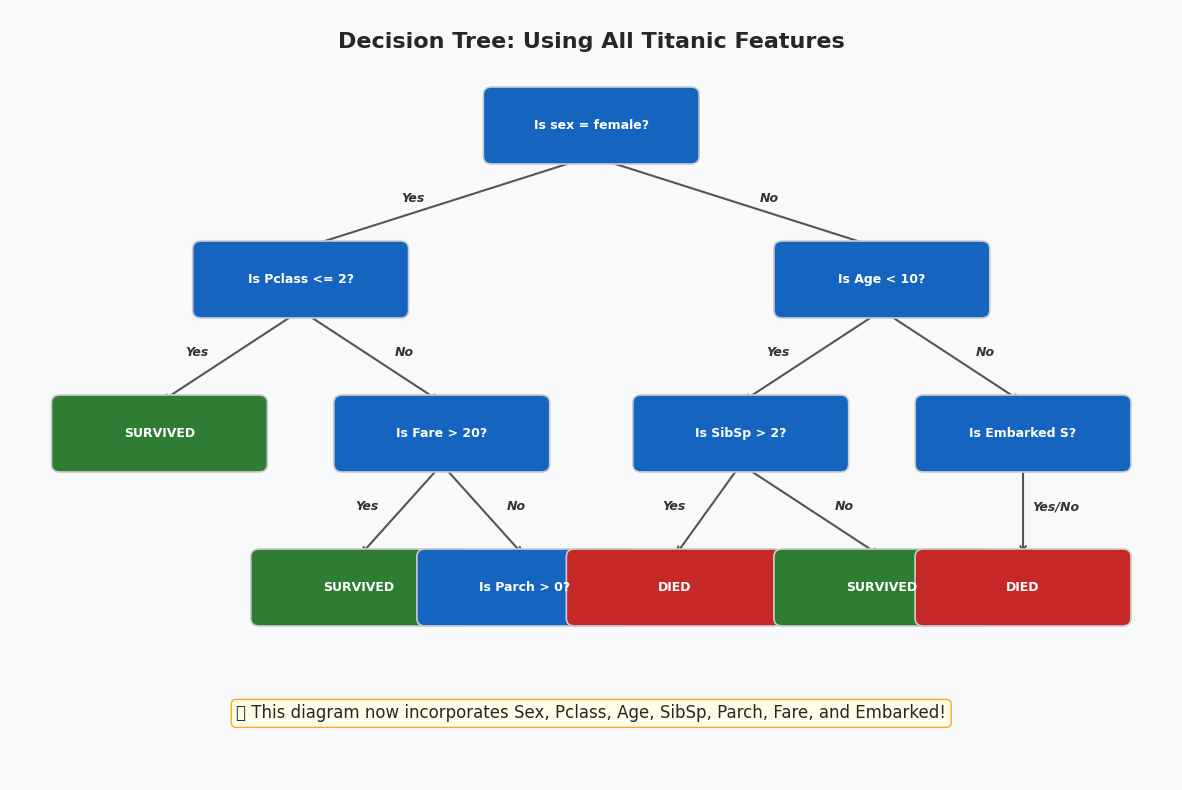

In [ ]:
# Prompt: Visualize a conceptual diagram of a Decision Tree for Titanic survival.
import warnings
import logging
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# 1. SILENCE WARNINGS
warnings.filterwarnings('ignore', category=UserWarning)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Font setup
mpl.rcParams['font.family'] = ['DejaVu Sans', 'sans-serif']
mpl.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(15, 10))
ax.set_xlim(0, 14); ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('#F8F9FA')

def draw_box(ax, x, y, text, color='#2E86AB', textcolor='white', w=2.4, h=0.8):
    p = FancyBboxPatch((x - w/2, y - h/2), w, h,
                        boxstyle='round,pad=0.1',
                        facecolor=color, edgecolor='#cccccc', linewidth=1.2, zorder=3)
    ax.add_patch(p)
    ax.text(x, y, text, ha='center', va='center', fontsize=9,
            color=textcolor, fontweight='bold', zorder=4)

def draw_arrow(ax, x1, y1, x2, y2, label='', side='left'):
    ax.annotate('', xy=(x2, y2 + 0.4), xytext=(x1, y1 - 0.4),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5), zorder=2)
    if label:
        lx, ly = (x1 + x2) / 2 + (-0.4 if side == 'left' else 0.4), (y1 + y2) / 2
        ax.text(lx, ly, label, fontsize=9, color='#333', style='italic', fontweight='bold', ha='center')

ax.text(7, 9.5, 'Decision Tree: Using All Titanic Features', fontsize=16, fontweight='bold', ha='center')

# Level 0
draw_box(ax, 7, 8.5, 'Is sex = female?', color='#1565C0')

# Level 1
draw_box(ax, 3.5, 6.5, 'Is Pclass <= 2?', color='#1565C0')
draw_box(ax, 10.5, 6.5, 'Is Age < 10?', color='#1565C0')

# Level 2 (Left side - Females)
draw_box(ax, 1.8, 4.5, 'SURVIVED', color='#2e7d32')
draw_box(ax, 5.2, 4.5, 'Is Fare > 20?', color='#1565C0')

# Level 2 (Right side - Males)
draw_box(ax, 8.8, 4.5, 'Is SibSp > 2?', color='#1565C0')
draw_box(ax, 12.2, 4.5, 'Is Embarked S?', color='#1565C0')

# Level 3 (Deep branches)
draw_box(ax, 4.2, 2.5, 'SURVIVED', color='#2e7d32')
draw_box(ax, 6.2, 2.5, 'Is Parch > 0?', color='#1565C0')
draw_box(ax, 8.0, 2.5, 'DIED', color='#c62828')
draw_box(ax, 10.5, 2.5, 'SURVIVED', color='#2e7d32')
draw_box(ax, 12.2, 2.5, 'DIED', color='#c62828')

# Connections L0 -> L1
draw_arrow(ax, 7, 8.5, 3.5, 6.5, 'Yes', 'left')
draw_arrow(ax, 7, 8.5, 10.5, 6.5, 'No', 'right')

# Connections L1 -> L2
draw_arrow(ax, 3.5, 6.5, 1.8, 4.5, 'Yes', 'left')
draw_arrow(ax, 3.5, 6.5, 5.2, 4.5, 'No', 'right')
draw_arrow(ax, 10.5, 6.5, 8.8, 4.5, 'Yes', 'left')
draw_arrow(ax, 10.5, 6.5, 12.2, 4.5, 'No', 'right')

# Connections L2 -> L3
draw_arrow(ax, 5.2, 4.5, 4.2, 2.5, 'Yes', 'left')
draw_arrow(ax, 5.2, 4.5, 6.2, 2.5, 'No', 'right')
draw_arrow(ax, 8.8, 4.5, 8.0, 2.5, 'Yes', 'left')
draw_arrow(ax, 8.8, 4.5, 10.5, 2.5, 'No', 'right')
draw_arrow(ax, 12.2, 4.5, 12.2, 2.5, 'Yes/No', 'right')

ax.text(7, 0.8, '💡 This diagram now incorporates Sex, Pclass, Age, SibSp, Parch, Fare, and Embarked!',
        fontsize=12, ha='center', bbox=dict(boxstyle='round', facecolor='#fffde7', edgecolor='#f9a825'))

plt.show()

### So, how does a Decision Tree decide *which question to ask first*?

It uses two main ideas:

#### 1. **Entropy:** How mixed up is the data?

Imagine a bag of candy:

*   🍬🍬🍬🍬 (All green) → **Low Entropy** (Very pure, easy to predict what you'll pick!)
*   🍬🍭🍬🍪 (Mixed colors and types) → **High Entropy** (Very mixed, hard to predict!)

In our Titanic data:

*   A group of passengers where `ALL` survived or `ALL` died has **low entropy** (pure).
*   A group where `half survived` and `half died` has **high entropy** (mixed).


#### 2. **Information Gain:** How much order does a question create?

Information Gain is like asking: **"How much does this question help me *reduce the chaos (entropy)* in the data?"**

The Decision Tree looks at all possible questions (e.g., "Is the passenger female?", "Is the passenger in 1st class?") and picks the one that makes the data **most organized** (lowest entropy) in the resulting groups.

**Example:**

If asking "Is the passenger female?" results in one group where 90% survived and another where 90% died, that question has **high information gain** because it helped sort the data into very pure groups.

Therefore, the tree will choose the question that provides the **highest Information Gain** to split the data at each step, starting with the root node.

---
### Let's look at the formulas and do some calculations!

#### Entropy Formula:

$ Entropy(S) = -\sum_{i=1}^{c} p_i \log_2(p_i) $

Where:
- $S$ is the dataset (or a subset of it).
- $c$ is the number of unique classes (e.g., 'Survived' or 'Not Survived').
- $p_i$ is the proportion of observations belonging to class $i$.

#### Information Gain Formula:

$ Gain(S, A) = Entropy(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} Entropy(S_v) $

Where:
- $S$ is the parent dataset.
- $A$ is the feature (attribute) we are splitting on (e.g., 'Sex').
- $Values(A)$ are the unique values of attribute $A$ (e.g., 'male', 'female').
- $|S_v|$ is the number of observations where attribute $A$ has value $v$.
- $|S|$ is the total number of observations in dataset $S$.

#### Intuition Behind the Formulas (Simplified):

**For Entropy:**

Think of it as **how much 'mess' or 'uncertainty' is in a group of data.**

*   The formula uses the **proportion ($p_i$)** of each outcome (e.g., how many survived vs. how many didn't).
*   It calculates the **average 'surprise'** you'd get when picking an item from that group.
*   **Higher Entropy = More mixed-up / Harder to predict.**
*   **Lower Entropy = More pure / Easier to predict.**

**For Information Gain:**

This measures **how much a question (feature) helps you *reduce the mess (entropy)* in the data.**

*   You start with the **mess of the whole group (initial Entropy)**.
*   Then, you calculate the **average mess of the smaller groups *after* you ask a question and split the data.**
*   **Information Gain = (Initial Mess) - (Average Mess After Question)**.
*   **A higher Information Gain means the question was very effective at sorting the data** and creating cleaner, less mixed-up groups. Decision Trees pick the question that gives the *highest* Information Gain.

### Let's Train a Decision Tree!

`max_depth=4` → the tree can ask **at most 4 questions** before giving an answer.

> ⚠️ Too deep → **Overfitting** (memorises training data, fails on new data)  
> ⚠️ Too shallow → **Underfitting** (too simple, misses patterns)  
> ✅ `max_depth=4` → a good balance for beginners!


In [ ]:
# Train the Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)          # LEARN from training data

y_pred_dt = dt.predict(X_test)   # PREDICT on new (test) data
acc_dt    = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy  : {acc_dt:.2%}")
print(f"   ✅ Correct predictions  : {int(acc_dt * len(y_test))} / {len(y_test)}")


Decision Tree Accuracy  : 78.77%
   ✅ Correct predictions  : 141 / 179


### 🔍 Let's *see* the actual tree the model learned!


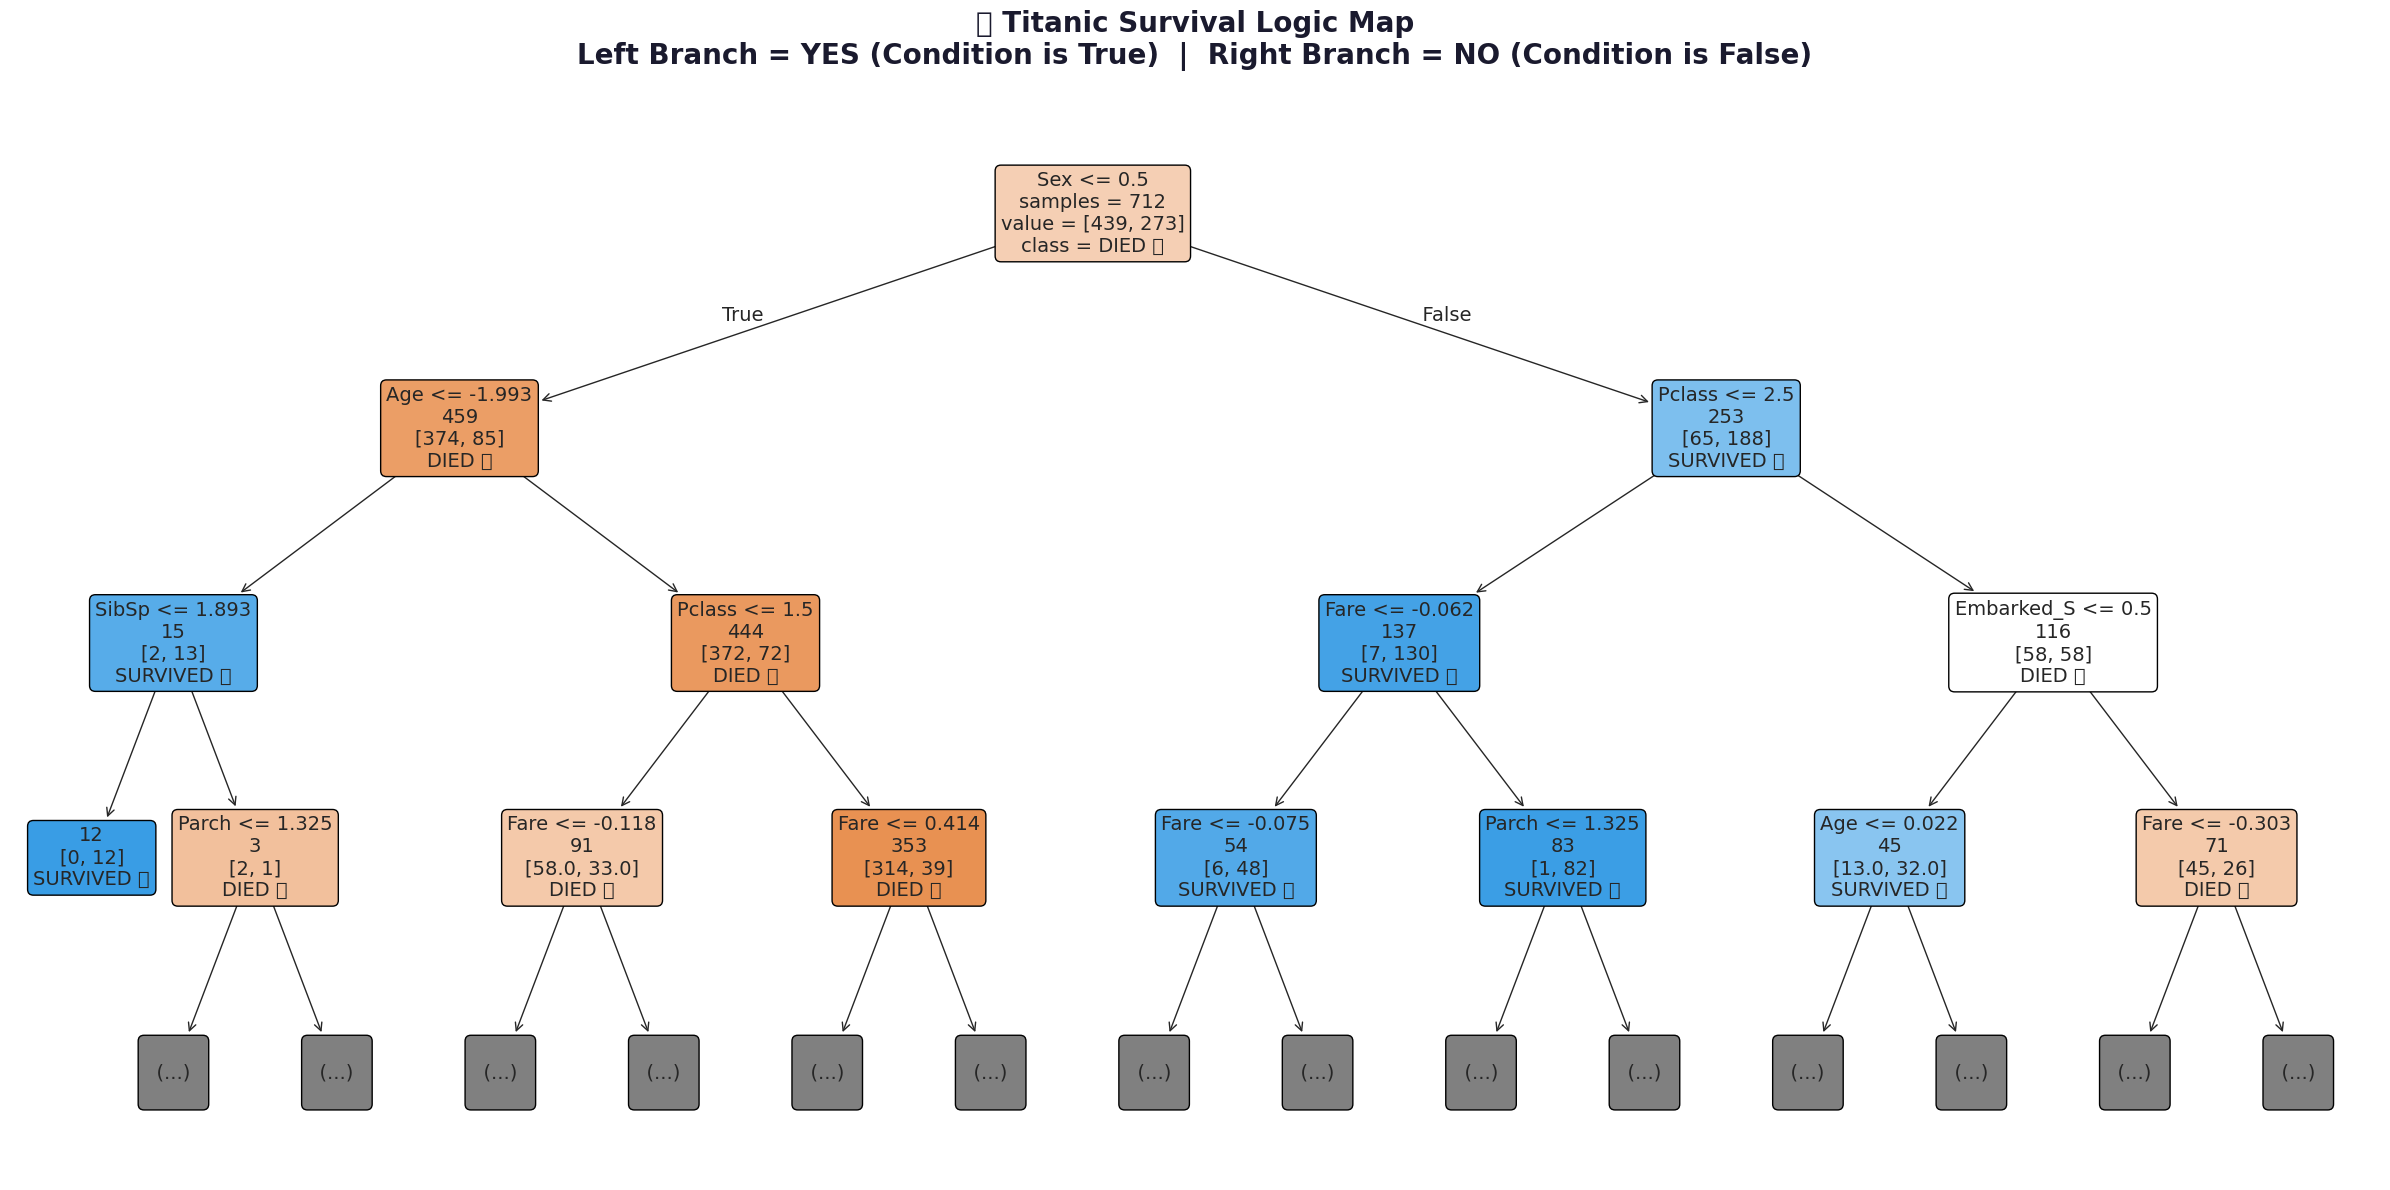

In [ ]:
# Prompt: Visualize the trained Decision Tree.
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 🌳 Presentation-Ready Visualization
plt.figure(figsize=(24, 12), dpi=100)

# We plot with higher contrast and clearer labels
plot_tree(dt,
          feature_names = X.columns.tolist(),
          class_names   = ['DIED ❌', 'SURVIVED ✅'],
          filled        = True,
          rounded       = True,
          proportion    = False,
          fontsize      = 14,
          max_depth     = 3,
          impurity      = False,
          node_ids      = False,
          label         = 'root')

plt.title('🚢 Titanic Survival Logic Map\n'
          'Left Branch = YES (Condition is True)  |  Right Branch = NO (Condition is False)',
          fontsize=20, fontweight='bold', pad=30, color='#1a1a2e')

plt.tight_layout()
plt.show()

---
### Feature Importance: What mattered most to the tree?

After training, the Decision Tree tells us **which features it relied on most**.  
This is called **Feature Importance**.

> **Higher score = more useful for making predictions**  
> Score of 0 = the model never used that feature  
> Scores always add up to 1.0


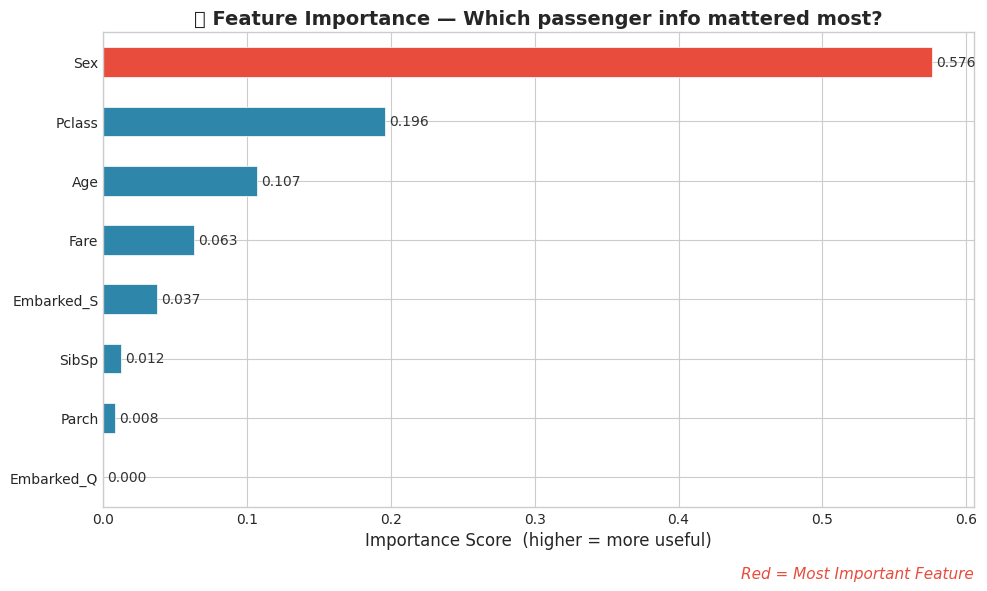

In [ ]:
# Prompt: Plot feature importance for the Decision Tree.
# Feature Importance - Decision Tree
feat_imp_dt = pd.Series(dt.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v == feat_imp_dt.max() else '#2E86AB' for v in feat_imp_dt.values]
feat_imp_dt.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)

ax.set_title('🔍 Feature Importance — Which passenger info mattered most?',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score  (higher = more useful)', fontsize=12)

for i, v in enumerate(feat_imp_dt.values):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=10, color='#333')

ax.text(1.0, -0.15, 'Red = Most Important Feature',
        transform=ax.transAxes, ha='right', fontsize=11,
        color='#e74c3c', style='italic')
plt.tight_layout()
plt.show()

---
## Part 2: Random Forest

### Problem with a single Decision Tree

One tree can be wrong.  
It might have "over-learned" patterns in the training data that don't exist in real life.

### Solution: Ask MANY trees and take a vote!

> Imagine you need to make a big decision.  
> Would you ask **1 person** or **100 different people** and go with the majority?

**Random Forest = 100+ Decision Trees, each trained slightly differently, voting together.**

---

### What makes each tree different?
- Each tree sees a **random sample** of the training data  
- Each tree uses a **random subset** of features  

→ This **diversity** makes the overall prediction much more reliable!


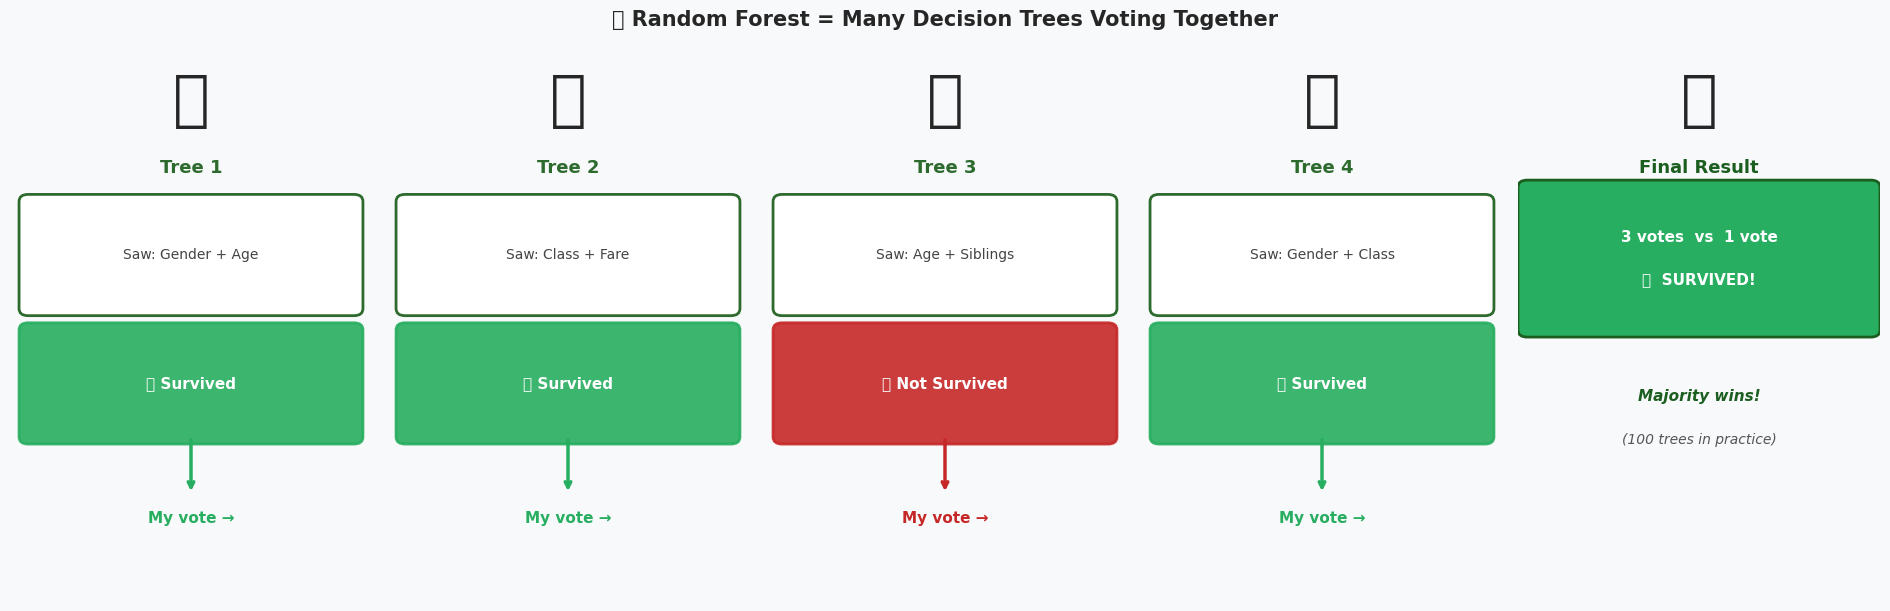

In [ ]:
# Prompt: Visualize a conceptual diagram of how Random Forest works with multiple trees voting.
# Concept Diagram — Random Forest (many trees voting)
fig, axes = plt.subplots(1, 5, figsize=(19, 6))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('🌲 Random Forest = Many Decision Trees Voting Together',
             fontsize=15, fontweight='bold', y=1.01)

tree_info = [
    ('Tree 1', 'Saw: Gender + Age',   '✅ Survived',    '#27ae60'),
    ('Tree 2', 'Saw: Class + Fare',   '✅ Survived',    '#27ae60'),
    ('Tree 3', 'Saw: Age + Siblings', '❌ Not Survived','#c62828'),
    ('Tree 4', 'Saw: Gender + Class', '✅ Survived',    '#27ae60'),
]

for ax, (name, saw, verdict, vcolor) in zip(axes[:4], tree_info):
    ax.set_facecolor('#F8F9FA')
    ax.axis('off'); ax.set_xlim(0, 4); ax.set_ylim(0, 7.5)

    ax.text(2, 7.0, '🌲', fontsize=44, ha='center', va='center')
    ax.text(2, 6.0, name, fontsize=13, ha='center',
            fontweight='bold', color='#2d6a2d')

    # Features it used
    p1 = FancyBboxPatch((0.2, 4.1), 3.6, 1.5, boxstyle='round,pad=0.1',
                          facecolor='white', edgecolor='#2d6a2d', linewidth=2)
    ax.add_patch(p1)
    ax.text(2, 4.85, saw, fontsize=10, ha='center', va='center', color='#444')

    # Verdict
    p2 = FancyBboxPatch((0.2, 2.3), 3.6, 1.5, boxstyle='round,pad=0.1',
                          facecolor=vcolor, edgecolor=vcolor, linewidth=2, alpha=0.9)
    ax.add_patch(p2)
    ax.text(2, 3.05, verdict, fontsize=11, ha='center', va='center',
            color='white', fontweight='bold')

    ax.annotate('', xy=(2, 1.5), xytext=(2, 2.3),
                arrowprops=dict(arrowstyle='->', color=vcolor, lw=2.5))
    ax.text(2, 1.1, 'My vote →', fontsize=11,
            ha='center', color=vcolor, fontweight='bold')

# Final verdict panel
ax5 = axes[4]
ax5.set_facecolor('#e8f5e9')
ax5.axis('off'); ax5.set_xlim(0, 4); ax5.set_ylim(0, 7.5)

ax5.text(2, 7.0, '🏆', fontsize=44, ha='center', va='center')
ax5.text(2, 6.0, 'Final Result', fontsize=13, ha='center',
         fontweight='bold', color='#1b5e20')

p3 = FancyBboxPatch((0.1, 3.8), 3.8, 2.0, boxstyle='round,pad=0.1',
                      facecolor='#27ae60', edgecolor='#1b5e20', linewidth=2)
ax5.add_patch(p3)
ax5.text(2, 4.8, '3 votes  vs  1 vote\n\n✅  SURVIVED!',
         fontsize=11, ha='center', va='center', color='white',
         fontweight='bold', linespacing=1.5)

ax5.text(2, 2.8, 'Majority wins!', fontsize=11,
         ha='center', color='#1b5e20', style='italic', fontweight='bold')
ax5.text(2, 2.2, '(100 trees in practice)', fontsize=10,
         ha='center', color='#555', style='italic')

plt.tight_layout()
plt.show()

In [ ]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators = 100,   # number of trees
    max_depth    = 4,
    random_state = 42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf    = accuracy_score(y_test, y_pred_rf)

print(f"🌳 Decision Tree  Accuracy : {acc_dt:.2%}")
print(f"🌲 Random Forest  Accuracy : {acc_rf:.2%}")
diff = (acc_rf - acc_dt) * 100
print(f"\n📈 Using 100 trees instead of 1 improved accuracy by: {diff:+.1f}%")


🌳 Decision Tree  Accuracy : 78.77%
🌲 Random Forest  Accuracy : 80.45%

📈 Using 100 trees instead of 1 improved accuracy by: +1.7%


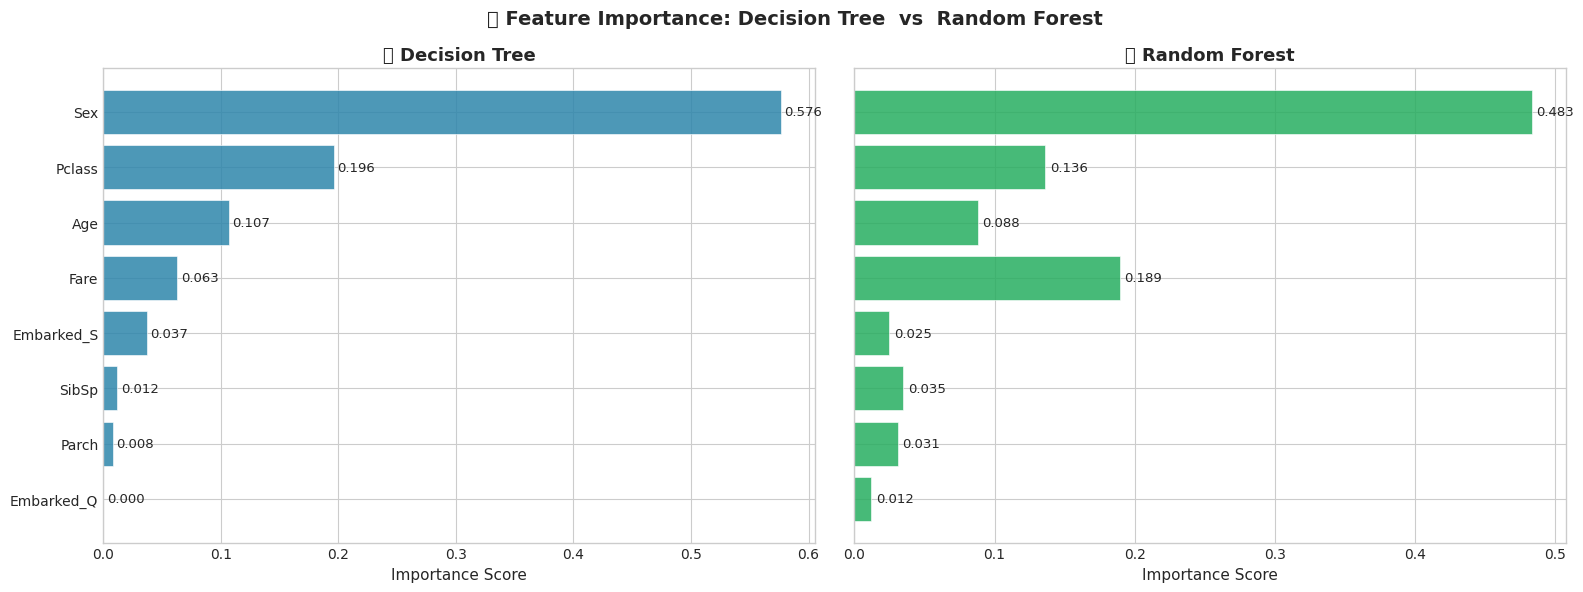


 Both models agree: Sex (Gender) is the #1 most important feature!
   Random Forest gives a more balanced, stable importance — it's not over-relying on one feature.


In [ ]:
# Prompt: Compare feature importances of Decision Tree and Random Forest.
# Feature Importance — DT vs RF side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('🔍 Feature Importance: Decision Tree  vs  Random Forest',
             fontsize=14, fontweight='bold')

dt_imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values()
rf_imp = pd.Series(rf.feature_importances_, index=X.columns).loc[dt_imp.index]

for ax, imp, title, clr in zip(
    axes,
    [dt_imp, rf_imp],
    ['🌳 Decision Tree', '🌲 Random Forest'],
    ['#2E86AB', '#27ae60']
):
    ax.barh(imp.index, imp.values, color=clr, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=11)
    for i, v in enumerate(imp.values):
        ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9.5)

plt.tight_layout()
plt.show()

print("\n Both models agree: Sex (Gender) is the #1 most important feature!")
print("   Random Forest gives a more balanced, stable importance — it's not over-relying on one feature.")

---
## Part 3: K-Nearest Neighbors (KNN)

### What is KNN?

> You move to a new neighbourhood. You want to know if it's safe.  
> You look at the **K nearest houses** around you.  
> If most of them are safe → you'll probably be safe too!

**KNN asks:**  
*"Who are this passenger's K closest 'data twins'? What happened to THEM?"*  
→ The new passenger gets the **majority label** of their nearest neighbours.

---

### What is K?

| K value | Behaviour |
|---------|-----------|
| Small K (e.g. 1, 3) | Very sensitive — may overfit to noise |
| Large K (e.g. 15, 20) | Very smooth — may miss real patterns |
| Best K | Found by **experimenting** on test data! |

> We'll try K = 1, 3, 5, 7, 9, 11, 15 and see which gives the best accuracy.


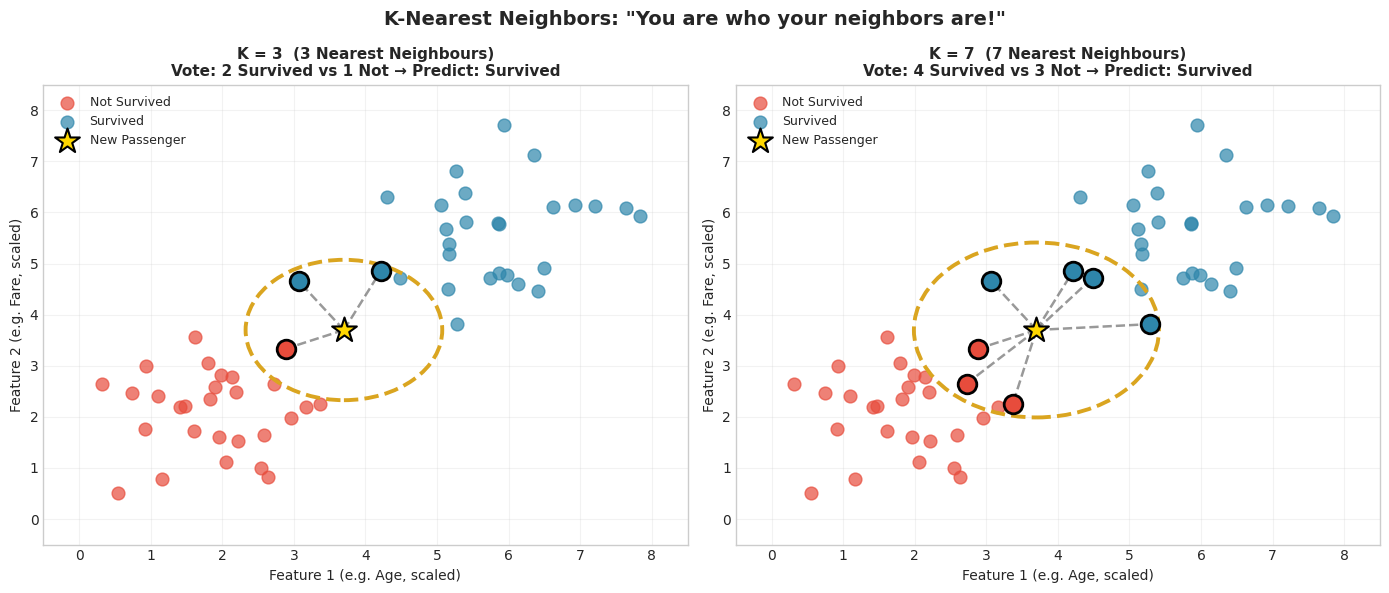


💡 Dashed circle = search area  |  Dashed lines = distance to each neighbour  |  ⭐ = new passenger


In [ ]:
# Prompt: Visualize a conceptual diagram of how K-Nearest Neighbors (KNN) works for different K values.
# Concept Diagram — How KNN works
np.random.seed(21)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('K-Nearest Neighbors: "You are who your neighbors are!"',
             fontsize=14, fontweight='bold')

# Simulated 2D data (just for illustration — not the real Titanic data)
c0x = np.random.normal(2.0, 0.85, 28)
c0y = np.random.normal(2.0, 0.85, 28)
c1x = np.random.normal(5.5, 0.85, 28)
c1y = np.random.normal(5.5, 0.85, 28)
new_pt = np.array([3.7, 3.7])

all_x  = np.concatenate([c0x, c1x])
all_y  = np.concatenate([c0y, c1y])
colors_pts = ['#e74c3c'] * 28 + ['#2E86AB'] * 28

for ax, K, title in zip(axes,
                         [3, 7],
                         ['K = 3  (3 Nearest Neighbours)', 'K = 7  (7 Nearest Neighbours)']):
    # Background points
    ax.scatter(c0x, c0y, c='#e74c3c', s=85,  label='Not Survived', zorder=3, alpha=0.7)
    ax.scatter(c1x, c1y, c='#2E86AB', s=85,  label='Survived',     zorder=3, alpha=0.7)
    # New passenger
    ax.scatter(*new_pt, c='gold', s=350, marker='*', label='New Passenger',
               zorder=6, edgecolors='black', linewidth=1.5)

    # Distances and nearest K
    dists      = np.sqrt((all_x - new_pt[0])**2 + (all_y - new_pt[1])**2)
    nearest_k  = np.argsort(dists)[:K]
    radius     = dists[nearest_k[-1]] * 1.08

    # Search circle
    circle = plt.Circle(new_pt, radius, fill=False, color='goldenrod',
                         linewidth=2.8, linestyle='--', zorder=4)
    ax.add_patch(circle)

    # Draw dashed lines to neighbours + highlight them
    for idx in nearest_k:
        ax.plot([new_pt[0], all_x[idx]], [new_pt[1], all_y[idx]],
                'k--', alpha=0.4, linewidth=1.8, zorder=5)
        ax.scatter(all_x[idx], all_y[idx], s=180, c=colors_pts[idx],
                   edgecolors='black', linewidth=2.0, zorder=7)

    # Tally the vote
    n_survived     = sum(1 for i in nearest_k if i >= 28)
    n_not_survived = K - n_survived
    result = 'Survived' if n_survived > n_not_survived else 'Not Survived '
    ax.set_title(f'{title}\nVote: {n_survived} Survived vs {n_not_survived} Not → Predict: {result}',
                 fontsize=11, fontweight='bold')

    ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim(-0.5, 8.5); ax.set_ylim(-0.5, 8.5)
    ax.set_xlabel('Feature 1 (e.g. Age, scaled)',  fontsize=10)
    ax.set_ylabel('Feature 2 (e.g. Fare, scaled)', fontsize=10)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()
print("\n💡 Dashed circle = search area  |  Dashed lines = distance to each neighbour  |  ⭐ = new passenger")

### Finding the Best K


In [ ]:
# Try different values of K
k_values = [1, 3, 5, 7, 9, 11, 15]
knn_accs = []

print("K    Accuracy")
print("─" * 22)
for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_tmp.predict(X_test))
    knn_accs.append(acc)
    print(f"K={k:2d}   {acc:.2%}")

best_k   = k_values[int(np.argmax(knn_accs))]
best_acc = max(knn_accs)
print(f"\nBest K = {best_k}  →  Accuracy = {best_acc:.2%}")


K    Accuracy
──────────────────────
K= 1   69.83%
K= 3   80.45%
K= 5   81.01%
K= 7   79.89%
K= 9   77.65%
K=11   78.77%
K=15   78.21%

Best K = 5  →  Accuracy = 81.01%


In [ ]:
# Train final KNN with the best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn    = accuracy_score(y_test, y_pred_knn)

print(f"Final KNN (K={best_k}) Accuracy: {acc_knn:.2%}")


Final KNN (K=5) Accuracy: 81.01%


---
## Part 4: Model Evaluation

### Why isn't accuracy always enough?

> **Imagine:** 90% of passengers didn't survive.  
> A model that **always says "Not Survived"** gets **90% accuracy** but it's completely useless!  
> It never correctly identifies a survivor!

We use the **Confusion Matrix** to see **exactly where** the model is right and wrong.

---

### The Confusion Matrix - 4 possible outcomes:

| | Predicted: Survived | Predicted: Not Survived |
|---|---|---|
| **Actual: Survived** | ✅ True Positive (TP) | ❌ False Negative (FN) |
| **Actual: Not Survived** | ❌ False Positive (FP) | ✅ True Negative (TN) |

**Accuracy = (TP + TN) / Total** ← we want this as high as possible  
**Green cells = correct predictions | Orange cells = mistakes**


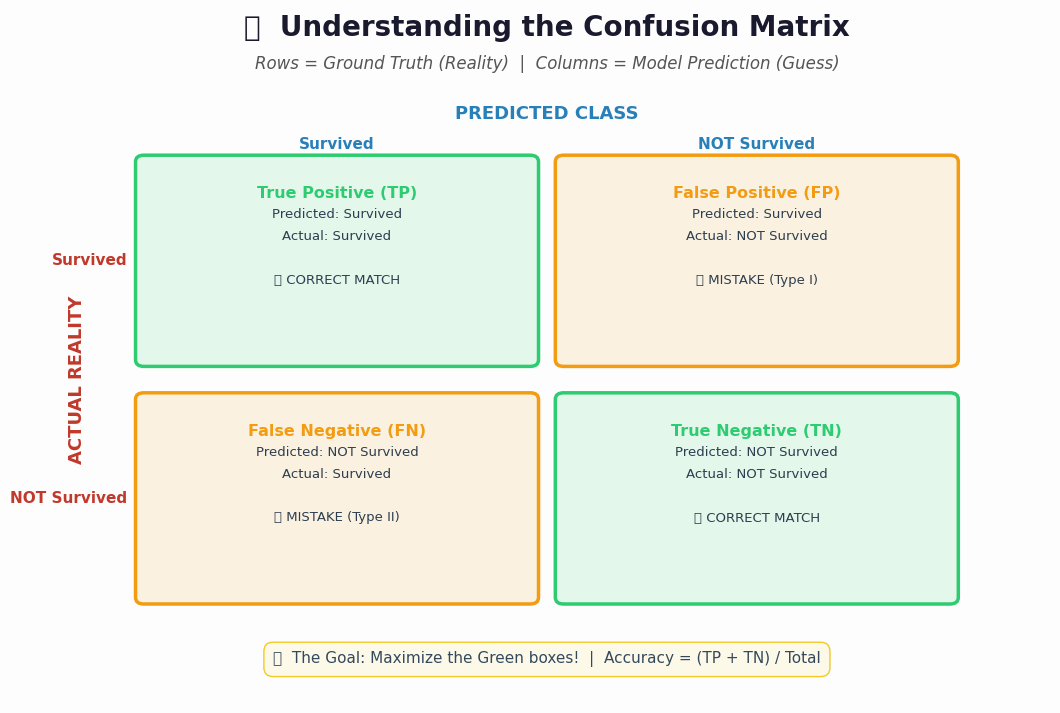

In [ ]:
# Prompt: Visualize a conceptual diagram of the Confusion Matrix.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# 🎨 Concept Diagram — Understanding the Confusion Matrix
fig, ax = plt.subplots(figsize=(13, 9))
ax.set_xlim(0, 12); ax.set_ylim(0, 10.5)
ax.axis('off')
fig.patch.set_facecolor('#FDFDFD')

# --- Header Section ---
ax.text(6, 10.1, '🔢  Understanding the Confusion Matrix', fontsize=20, fontweight='bold', ha='center', color='#1a1a2e')
ax.text(6, 9.6, 'Rows = Ground Truth (Reality)  |  Columns = Model Prediction (Guess)', fontsize=12, ha='center', color='#555', style='italic')

# --- Quadrant Configuration (x, y, Title, Outcome, Color) ---
quad_info = [
    (3.5, 6.7, 'True Positive (TP)',  'Predicted: Survived\nActual: Survived\n\n✅ CORRECT MATCH', '#2ecc71'),
    (8.5, 6.7, 'False Positive (FP)', 'Predicted: Survived\nActual: NOT Survived\n\n❌ MISTAKE (Type I)', '#f39c12'),
    (3.5, 3.1, 'False Negative (FN)', 'Predicted: NOT Survived\nActual: Survived\n\n❌ MISTAKE (Type II)', '#f39c12'),
    (8.5, 3.1, 'True Negative (TN)',  'Predicted: NOT Survived\nActual: NOT Survived\n\n✅ CORRECT MATCH', '#2ecc71'),
]

for cx, cy, title, desc, color in quad_info:
    # Background Block - Taller height (3.0) to prevent text overflow
    ax.add_patch(FancyBboxPatch((cx - 2.3, cy - 1.5), 4.6, 3.0, boxstyle='round,pad=0.1', facecolor=color, edgecolor=color, linewidth=2, alpha=0.12))
    # Outer Frame
    ax.add_patch(FancyBboxPatch((cx - 2.3, cy - 1.5), 4.6, 3.0, boxstyle='round,pad=0.1', facecolor='none', edgecolor=color, linewidth=2.5))
    # Text Elements - Smaller font and wider spacing
    ax.text(cx, cy + 0.95, title, fontsize=11.5, ha='center', fontweight='bold', color=color)
    ax.text(cx, cy - 0.35, desc, fontsize=9.5, ha='center', color='#2c3e50', linespacing=1.9)

# --- Structural Axis Titles ---
ax.text(6.0, 8.85, 'PREDICTED CLASS', fontsize=13, fontweight='black', color='#2980b9', ha='center')
ax.text(3.5, 8.4, 'Survived', fontsize=11, fontweight='bold', color='#2980b9', ha='center')
ax.text(8.5, 8.4, 'NOT Survived', fontsize=11, fontweight='bold', color='#2980b9', ha='center')

ax.text(0.3, 4.9, 'ACTUAL REALITY', fontsize=13, fontweight='black', color='#c0392b', rotation=90, va='center')
ax.text(1.0, 6.7, 'Survived', fontsize=11, fontweight='bold', color='#c0392b', ha='right', va='center')
ax.text(1.0, 3.1, 'NOT Survived', fontsize=11, fontweight='bold', color='#c0392b', ha='right', va='center')

# --- Summary Footer Block ---
footer_text = '💡  The Goal: Maximize the Green boxes!  |  Accuracy = (TP + TN) / Total'
ax.text(6, 0.6, footer_text, fontsize=11, ha='center', color='#34495e',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#FEF9E7', edgecolor='#F1C40F', alpha=0.9))

plt.show()

### Now let's see the confusion matrices for all 3 models!


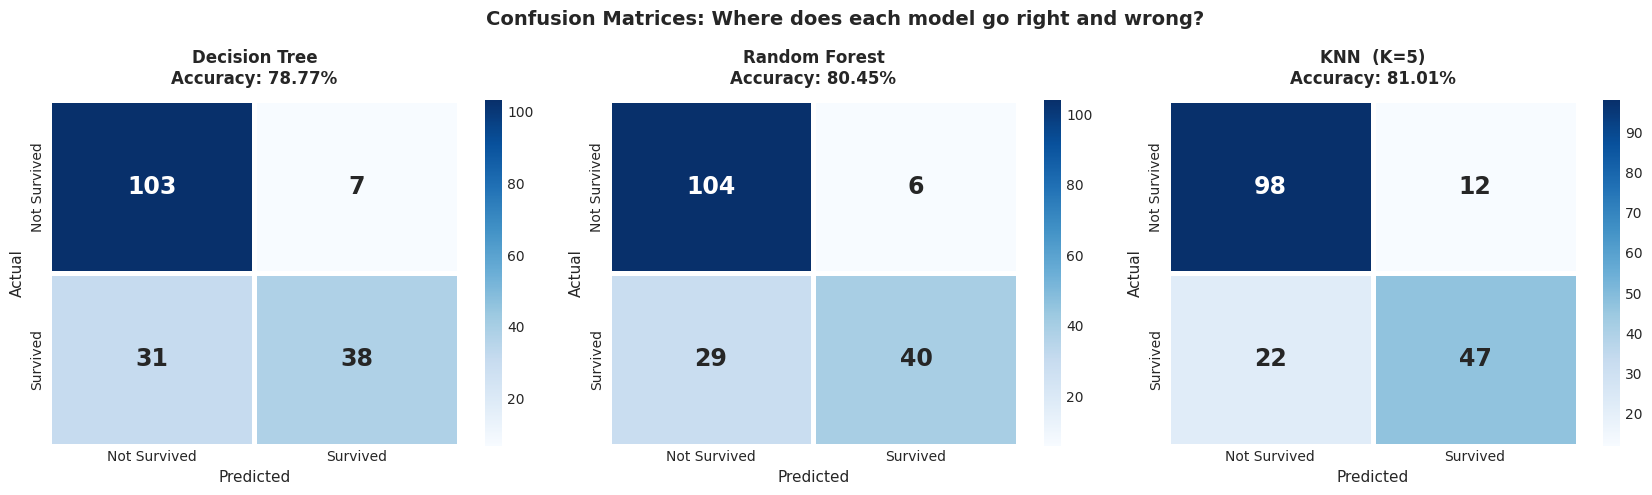


📖 How to read: Rows = actual class  |  Columns = predicted class
   Diagonal (top-left, bottom-right) = correct predictions  ✅
   Off-diagonal = mistakes  ❌


In [ ]:
# Prompt: Plot confusion matrices for Decision Tree, Random Forest, and KNN models.
# Confusion Matrices — All 3 Models
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Confusion Matrices: Where does each model go right and wrong?',
             fontsize=14, fontweight='bold')

model_results = [
    ('Decision Tree',        y_pred_dt,  acc_dt),
    ('Random Forest',        y_pred_rf,  acc_rf),
    (f'KNN  (K={best_k})',   y_pred_knn, acc_knn),
]

for ax, (name, preds, acc) in zip(axes, model_results):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'],
                linewidths=2.5, linecolor='white',
                annot_kws={'size': 17, 'weight': 'bold'})
    ax.set_title(f'{name}\nAccuracy: {acc:.2%}', fontsize=12, fontweight='bold', pad=12)
    ax.set_ylabel('Actual',    fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.show()

print("\n📖 How to read: Rows = actual class  |  Columns = predicted class")
print("   Diagonal (top-left, bottom-right) = correct predictions  ✅")
print("   Off-diagonal = mistakes  ❌")

---
## Session Summary

| Model | How it thinks | Analogy | Strength | Weakness |
|-------|--------------|---------|----------|----------|
| **Decision Tree** | Asks YES/NO questions | 20 Questions game | Easy to visualise & explain | Can overfit |
| **Random Forest** | 100s of trees vote | Asking 100 friends | Usually more accurate | Hard to interpret |
| **KNN** | Looks at nearest neighbours | Moving to a new neighbourhood | Simple & intuitive | Slow on large datasets |

---

### Key Takeaways

1. **Decision Tree** = a flowchart of questions the model learned from data  
2. **Random Forest** = many trees → usually beats a single tree  
3. **Feature Importance** = tells us *which features actually mattered*  
4. **KNN** = "guilt by association" → classify by looking at neighbours  
5. **Confusion Matrix** = shows exactly *where* the model is right and wrong  
6. **Accuracy** = (correct predictions) / (total predictions)

---